In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [30]:
X, y = make_moons(100, noise=0.25,random_state=2)

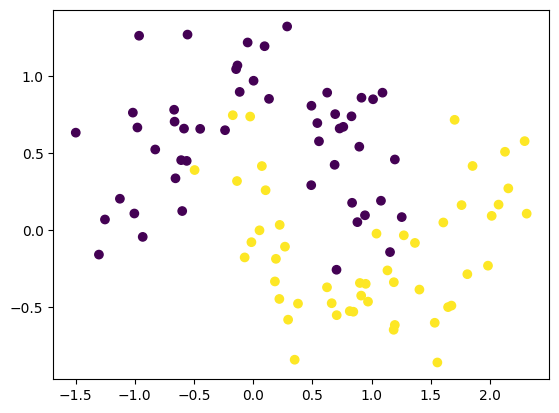

In [31]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [32]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
    
history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 2s 249us/step


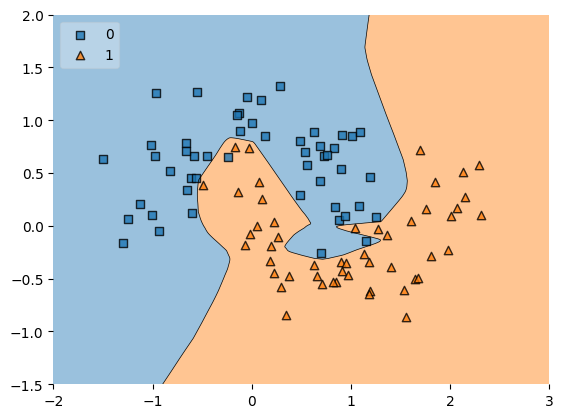

In [34]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

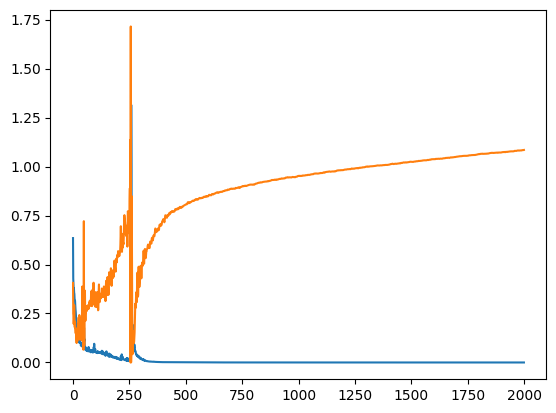

In [35]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [36]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 2s 245us/step


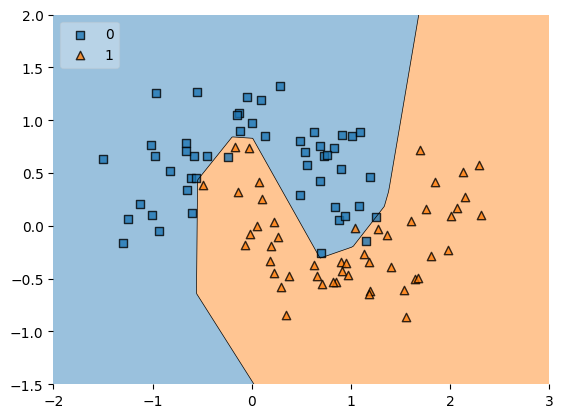

In [38]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

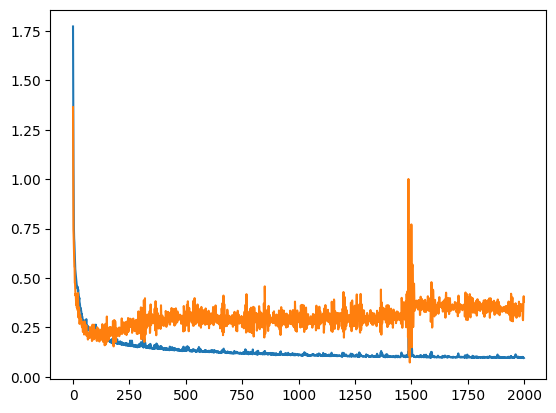

In [39]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [40]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

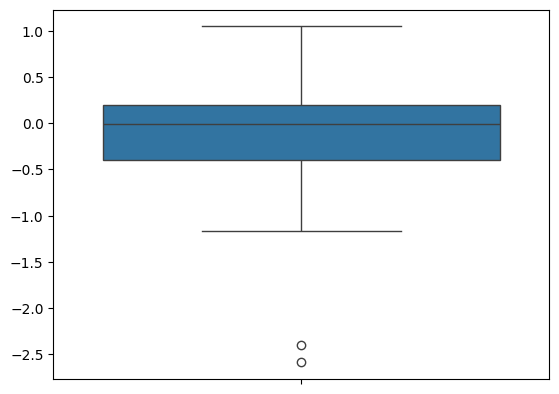

In [41]:
sns.boxplot(model1_weight_layer1)

<Axes: >

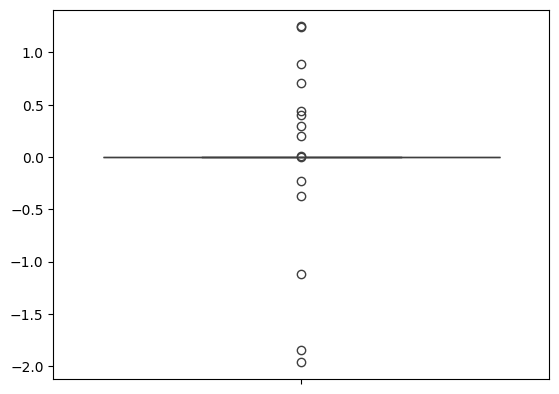

In [42]:
sns.boxplot(model2_weight_layer1)

In [43]:
model1_weight_layer1.min()

np.float32(-2.5867534)

In [44]:
model2_weight_layer1.min()

np.float32(-1.9640279)

/var/folders/9v/xp4ypl7x41q8xv91t5m0dv2c0000gn/T/ipykernel_11167/2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/var/folders/9v/xp4ypl7x41q8xv91t5m0dv2c0000gn/T/ipykernel_11167/2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_laye

<Axes: ylabel='Density'>

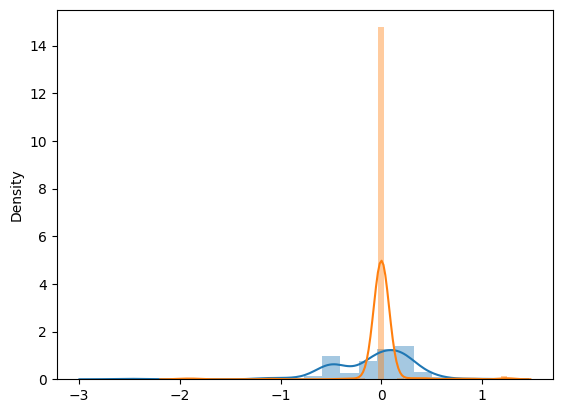

In [45]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [46]:
model1.get_weights()[0].reshape(256)

array([ 2.10531637e-01,  2.62173444e-01,  3.61367576e-02, -3.81091721e-02,
        2.35992208e-01, -6.78734303e-01, -1.91728830e-01, -5.15221238e-01,
       -3.96685928e-01,  7.61268884e-02,  2.01887667e-01,  2.19770297e-01,
        2.20474601e-01,  5.29013239e-02, -9.28264856e-02, -5.88473797e-01,
        6.93192035e-02,  6.06384650e-02, -2.82113310e-02, -4.44665283e-01,
        3.70792121e-01,  2.25165218e-01,  3.91507834e-01,  4.16104972e-01,
       -4.37838554e-01,  3.88331085e-01,  1.46003470e-01,  1.53859898e-01,
        3.41653563e-02,  1.47375107e-01,  2.42949324e-03, -5.69207609e-01,
        6.96990546e-03,  2.04883993e-01,  6.04763441e-02,  1.67141795e-01,
       -6.49612546e-02, -5.85108638e-01, -4.34021115e-01, -5.96914589e-01,
       -4.72146749e-01,  5.05300704e-03,  2.51702696e-01, -3.75587314e-01,
       -3.19706313e-02, -1.08921334e-01,  9.64088067e-02, -2.83596274e-02,
       -4.98750001e-01, -4.54092771e-01,  7.32722180e-03, -4.81216103e-01,
        7.31684193e-02, -